/workspace/src/utils/dataset.py:69: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda z: 1 / (1 + np.exp(-z))


Running for LogisticAnisotropicDataset
Starting Full Dataset Geometric Analysis
--- Scaling features to remove scale-based anisotropy ---
Scaling complete.

--- Analyzing feature correlation ---


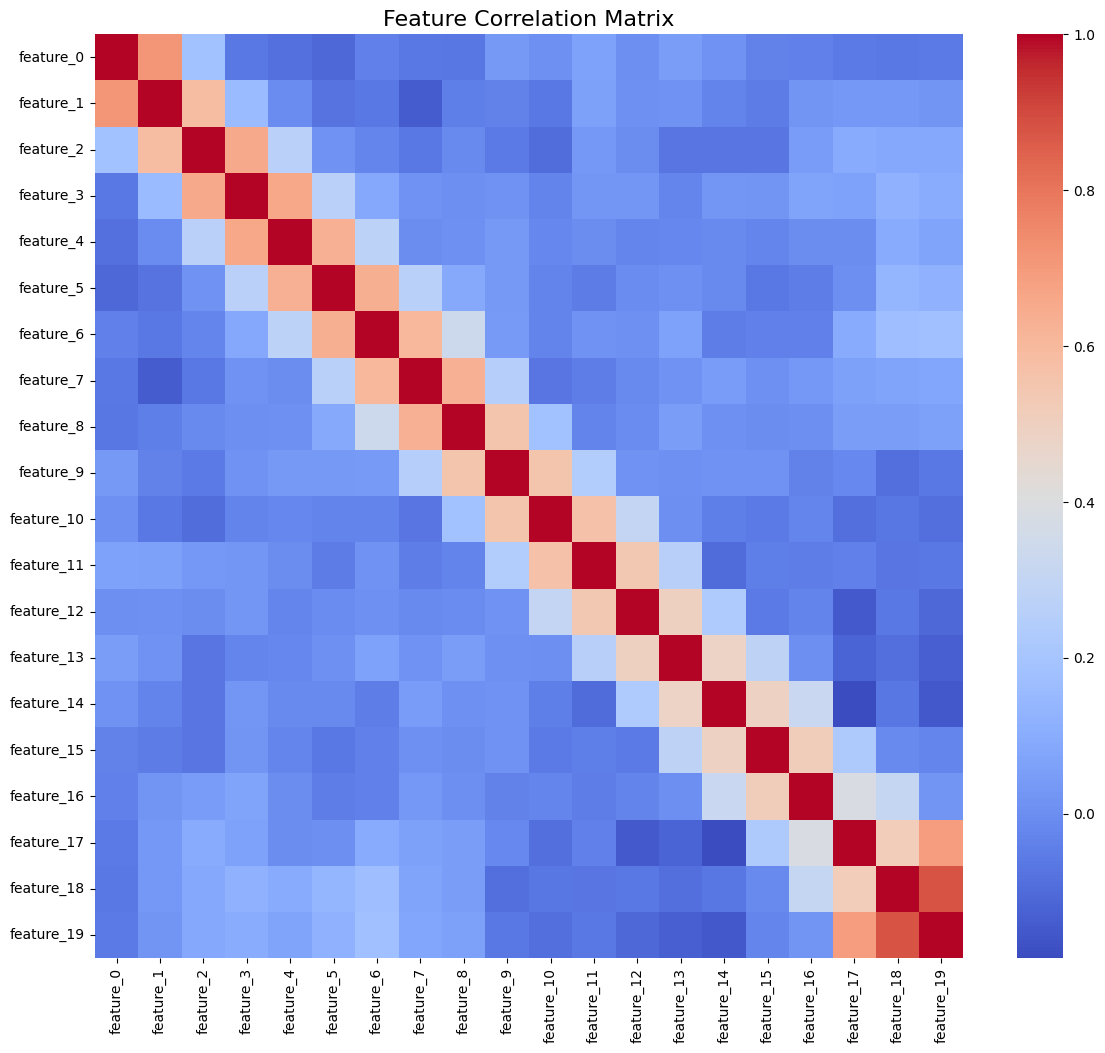


--- Analyzing structural anisotropy with PCA ---


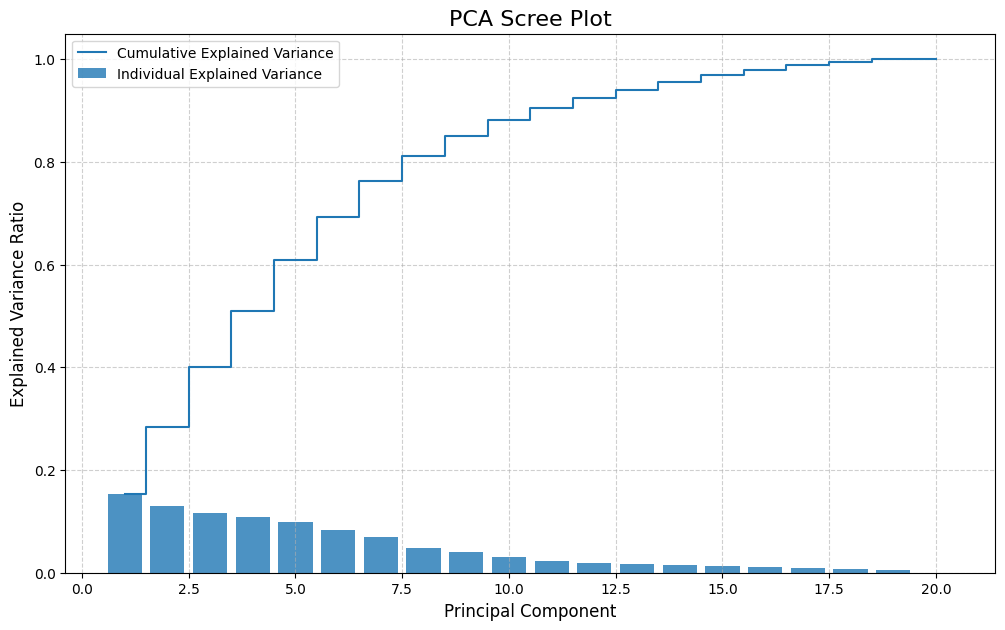


Analysis complete. See plots for visualization.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
import libcontext


from  src.utils.dataset import AustralianCreditDataset, HeartDataset, MNISTDataWrapper, SpliceDataset, IsotropicDataset, AnisotropicDataset, CorrelatedAnisotropicDataset, LogisticAnisotropicDataset



class DatasetAnalyzer:
    def __init__(self, dataset_loader):
        """
        Initializes the analyzer with a data loading object.
        
        Args:
            dataset_loader: An object with a 'get_data_for_analysis' method
                            that returns X (pd.DataFrame) and y (np.array).
        """
        self.loader = dataset_loader
        self.X_raw, self.y_raw = self.loader.get_data_for_analysis()
        self.X_scaled_df = None

    def _scale_features(self):
        """Scales the features using StandardScaler."""
        print("--- Scaling features to remove scale-based anisotropy ---")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X_raw)
        self.X_scaled_df = pd.DataFrame(X_scaled, columns=self.X_raw.columns)
        print("Scaling complete.")

    def analyze_correlation(self):
        """Calculates and visualizes the feature correlation matrix."""
        if self.X_scaled_df is None:
            self._scale_features()
            
        print("\n--- Analyzing feature correlation ---")
        correlation_matrix = self.X_raw.corr()
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".1f")
        plt.title('Feature Correlation Matrix', fontsize=16)
        plt.show()

    def analyze_isotropy_with_pca(self):
        """Performs PCA to analyze structural anisotropy."""
        # if self.X_scaled_df is None:
        #     self._scale_features()

        print("\n--- Analyzing structural anisotropy with PCA ---")
        pca = PCA()
        pca.fit(self.X_raw)
        
        explained_variance_ratio = pca.explained_variance_ratio_

        plt.figure(figsize=(12, 7))
        plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.8, align='center', label='Individual Explained Variance')
        plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative Explained Variance')
        plt.ylabel('Explained Variance Ratio', fontsize=12)
        plt.xlabel('Principal Component', fontsize=12)
        plt.title('PCA Scree Plot', fontsize=16)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    def run_full_analysis(self):
        """Runs all analysis steps in sequence."""
        print("="*50)
        print("Starting Full Dataset Geometric Analysis")
        print("="*50)
        self.analyze_correlation()
        self.analyze_isotropy_with_pca()
        print("\nAnalysis complete. See plots for visualization.")
        print("="*50)


# --- Main Execution ---
if __name__ == "__main__":
    # 1. Create an instance of your data loade
    # loaders = {"AU": AustralianCreditDataset(), "Heart": HeartDataset(), "Splice": SpliceDataset()}
    n_samples = 300
    in_dim = 20
    out_dim = 2
    test_size = 0.2
    seed = 10

    loaders = {
        "LogisticAnisotropicDataset": LogisticAnisotropicDataset(n_samples=n_samples, in_dim=in_dim, out_dim=out_dim, seed=seed,),
        # "Anisotropic": AnisotropicDataset(n_samples=n_samples, in_dim=in_dim, out_dim=out_dim, seed=seed,), 
        # "CorrelatedAnisotropic": CorrelatedAnisotropicDataset(n_samples=n_samples,in_dim=in_dim,out_dim=out_dim,seed=seed,)
        }
    
    for loader_name in loaders.keys():
        # 2. Pass it to the analyzer
        analyzer = DatasetAnalyzer(loaders[loader_name])

        print(f"Running for {loader_name}") 
        # 3. Run the full analysis
        analyzer.run_full_analysis()